# Futile Stock Price Prediction with LSTM and GRU

This project predicts stock prices based on historical financial data using RNN LSTM.  It is a good practice of LSTM but does absolutely nothing for financial speculation as I believe stock prices follow a random walk process.


After you upgraded pandas and pandas-datareader, restart runtime before excuting the following codes.

In [40]:
import math
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [41]:
# Get the stock quote
# df = web.DataReader('PFE', data_source='yahoo', start='2010-01-01', end='2021-10-20')
# print(df.head())
# print(df)

In [42]:
# Get the stock quote
df = yf.download('PFE', start='2010-01-01', end='2023-02-20')
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open    Volume
Ticker           PFE       PFE       PFE       PFE       PFE
Date                                                        
2010-01-04  9.200831  9.205692  8.865461  8.880042  54898644
2010-01-05  9.069602  9.200834  9.016137  9.195974  45714931
2010-01-06  9.040437  9.142507  8.996693  9.069600  43640975
2010-01-07  9.006413  9.074460  8.972390  9.059878  41557112
2010-01-08  9.079323  9.093904  9.001556  9.050161  32049716


(3305, 5)


<function matplotlib.pyplot.show(close=None, block=None)>

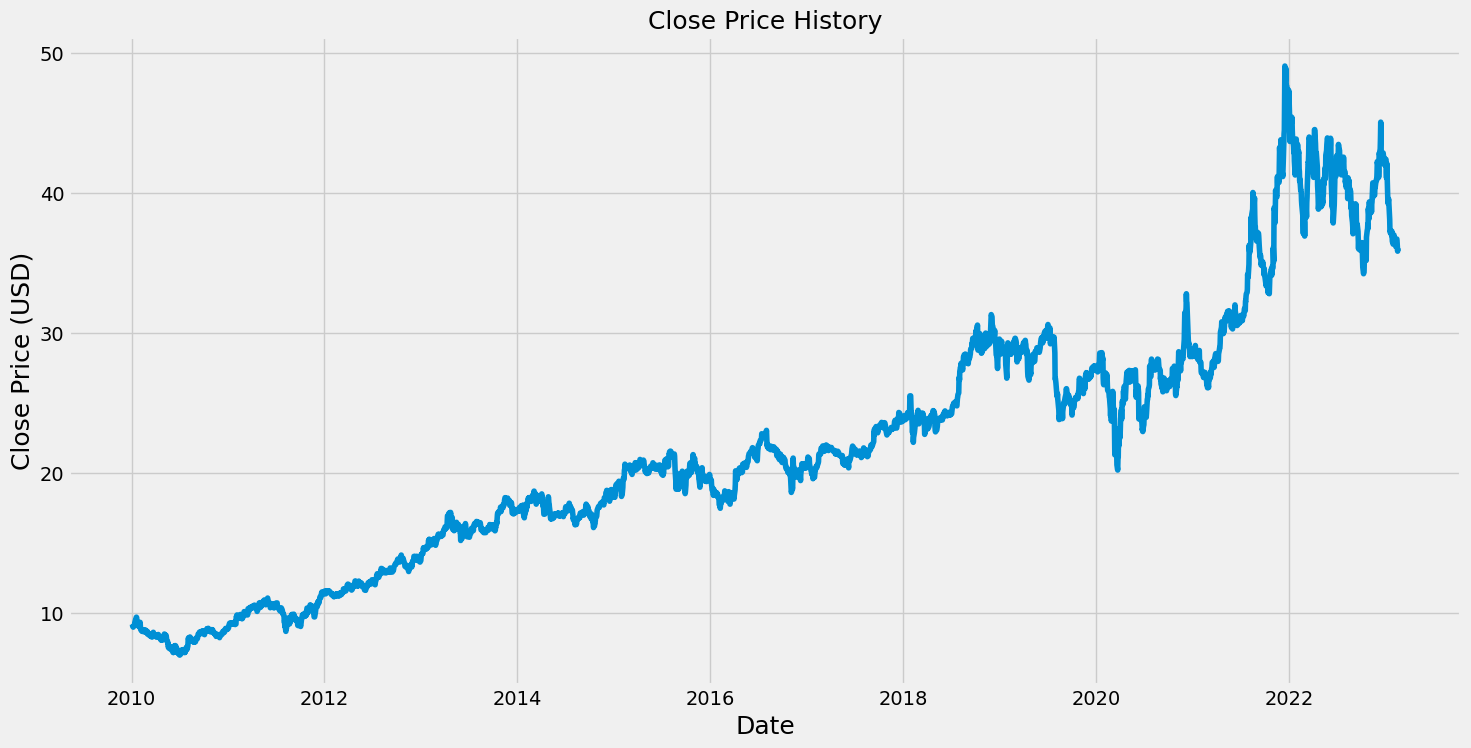

In [43]:
# Get the number of rows and columns in the data set
print(df.shape)
# Visualize the closing price history
plt.figure(figsize=(16,8))
plt.plot(df['Close'])
plt.title('Close Price History', fontsize=18)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD)', fontsize=18)
plt.show

In [44]:
# Create a new dataframe with only the Close column
dataset = df['Close'].values.reshape(-1, 1)
# Convert the dataframe to a numpy array
training_data_len = math.ceil(len(dataset) * .8)
# Get the number of rows to train the model on
print("Training rows:", training_data_len)

Training rows: 2644


In [45]:
# Scale the data
train_data = dataset[0:training_data_len, :]
scaler = MinMaxScaler(feature_range=(0,1))
scaler.fit(train_data)
scaled_data = scaler.transform(dataset)
print("Scaled data length:", len(scaled_data))
print("Scaled data shape:", scaled_data.shape)

Scaled data length: 3305
Scaled data shape: (3305, 1)


In [46]:
# Create the training dataset
# Create the scaled training dataset
train_data = scaled_data[0:training_data_len, :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

sequence_len = 80

for i in range(sequence_len, len(train_data)):
  x_train.append(train_data[i-sequence_len:i, 0])
  y_train.append(train_data[i, 0])
  if i<=sequence_len+1:
    print(x_train)
    print(y_train)
    print()

[array([0.09012122, 0.0847213 , 0.08352119, 0.08212117, 0.0851213 ,
       0.08812115, 0.08692115, 0.09572124, 0.09912133, 0.10132134,
       0.11152141, 0.11032161, 0.09632122, 0.09072116, 0.08852115,
       0.08712117, 0.09152128, 0.08412128, 0.0847213 , 0.08732131,
       0.09632122, 0.08743806, 0.07552655, 0.07411339, 0.07169063,
       0.07249824, 0.0696718 , 0.07229634, 0.07088318, 0.06926792,
       0.06825849, 0.06946986, 0.0747189 , 0.07391141, 0.06825849,
       0.07108493, 0.06866237, 0.06583589, 0.06987371, 0.06684536,
       0.06119244, 0.06139435, 0.06442253, 0.06179803, 0.05937532,
       0.0577603 , 0.06058674, 0.05634706, 0.05998111, 0.05998111,
       0.05897152, 0.05937532, 0.05291491, 0.0577603 , 0.06563399,
       0.06704723, 0.06260549, 0.05755828, 0.06038491, 0.05998111,
       0.0577603 , 0.05634706, 0.0527132 , 0.05392442, 0.05614519,
       0.05755828, 0.05977909, 0.06058674, 0.05836604, 0.05614519,
       0.05453013, 0.05069418, 0.05049219, 0.04988653, 0.0466

In [47]:
type(x_train)

list

In [48]:
# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)
display(type(x_train))
display(x_train.shape)

# Reshape the data for the LSTM model
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
display(x_train.shape[1])

numpy.ndarray

(2564, 80)

80

**Long Short Term Memory (LSTM) Network**

<!-- ![alt text](http://colah.github.io/images/post-covers/lstm.png) -->
![alt text](https://www.researchgate.net/profile/Savvas-Varsamopoulos/publication/329362532/figure/fig5/AS:699592479870977@1543807253596/Structure-of-the-LSTM-cell-and-equations-that-describe-the-gates-of-an-LSTM-cell.jpg)


**Gated Recurrent Unit (GRU)**

![alt text](https://upload.wikimedia.org/wikipedia/commons/thumb/3/37/Gated_Recurrent_Unit%2C_base_type.svg/2880px-Gated_Recurrent_Unit%2C_base_type.svg.png)

Initially, for $t=0$, the output vector is $h_{0}=0$.

\begin{aligned}z_{t}&=\sigma _{g}(W_{z}x_{t}+U_{z}h_{t-1}+b_{z})\\r_{t}&=\sigma _{g}(W_{r}x_{t}+U_{r}h_{t-1}+b_{r})\\{\hat {h}}_{t}&=\phi _{h}(W_{h}x_{t}+U_{h}(r_{t}\odot h_{t-1})+b_{h})\\h_{t}&=(1-z_{t})\odot h_{t-1}+z_{t}\odot {\hat {h}}_{t}\end{aligned}

where, the operator $\odot$  denotes the Hadamard product.

Variables
- $x_{t}$: input vector
- $h_{t}$: output vector
- $\hat{h}_{t}$: candidate activation vector
- $z_{t}$: update gate vector
- $r_{t}$: reset gate vector
- $W$, $U$ and $b$: parameter matrices and vector


Activation functions
- $\sigma _{g}$: The original is a sigmoid function.
- $\phi _{h}$: The original is a hyperbolic tangent.



In [49]:
# Build the LSTM and GRU model
model = Sequential()
model.add(LSTM(80, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(GRU(80, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

d:\Education\PhD\Courses\3_DeepLearning\Assignments\Repo\202610ELC536501\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [50]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 80, 80)         │        26,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 80)             │        38,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 25)             │         2,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,171 (262.39 KB)

 Trainable params: 67,171 (262.39 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

In [52]:
# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=10)

Epoch 1/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 44s 16ms/step - loss: 0.0012
Epoch 2/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - loss: 4.4512e-04
Epoch 3/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 53s 21ms/step - loss: 3.9302e-04
Epoch 4/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 55s 21ms/step - loss: 3.4244e-04
Epoch 5/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 56s 22ms/step - loss: 3.2751e-04
Epoch 6/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 59s 23ms/step - loss: 2.7557e-04
Epoch 7/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 74s 29ms/step - loss: 2.7237e-04
Epoch 8/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 63s 25ms/step - loss: 2.8803e-04
Epoch 9/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 42s 16ms/step - loss: 2.5029e-04
Epoch 10/10
2564/2564 ━━━━━━━━━━━━━━━━━━━━ 41s 16ms/step - loss: 2.6480e-04


In [53]:
# Create the testing data set
# Create a new array containing scaled values indexed from (training_data_len - sequence_len) to the end.
test_data = scaled_data[training_data_len - sequence_len:, :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]

for i in range(sequence_len, len(test_data)):
  x_test.append(test_data[i-sequence_len:i, 0])

In [54]:
# Convert the data to a numpy array
x_test = np.array(x_test)

In [55]:
# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

In [56]:
# Get the model's predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


In [57]:
# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(predictions - y_test)**2)
print(rmse)

1.0555585350463683


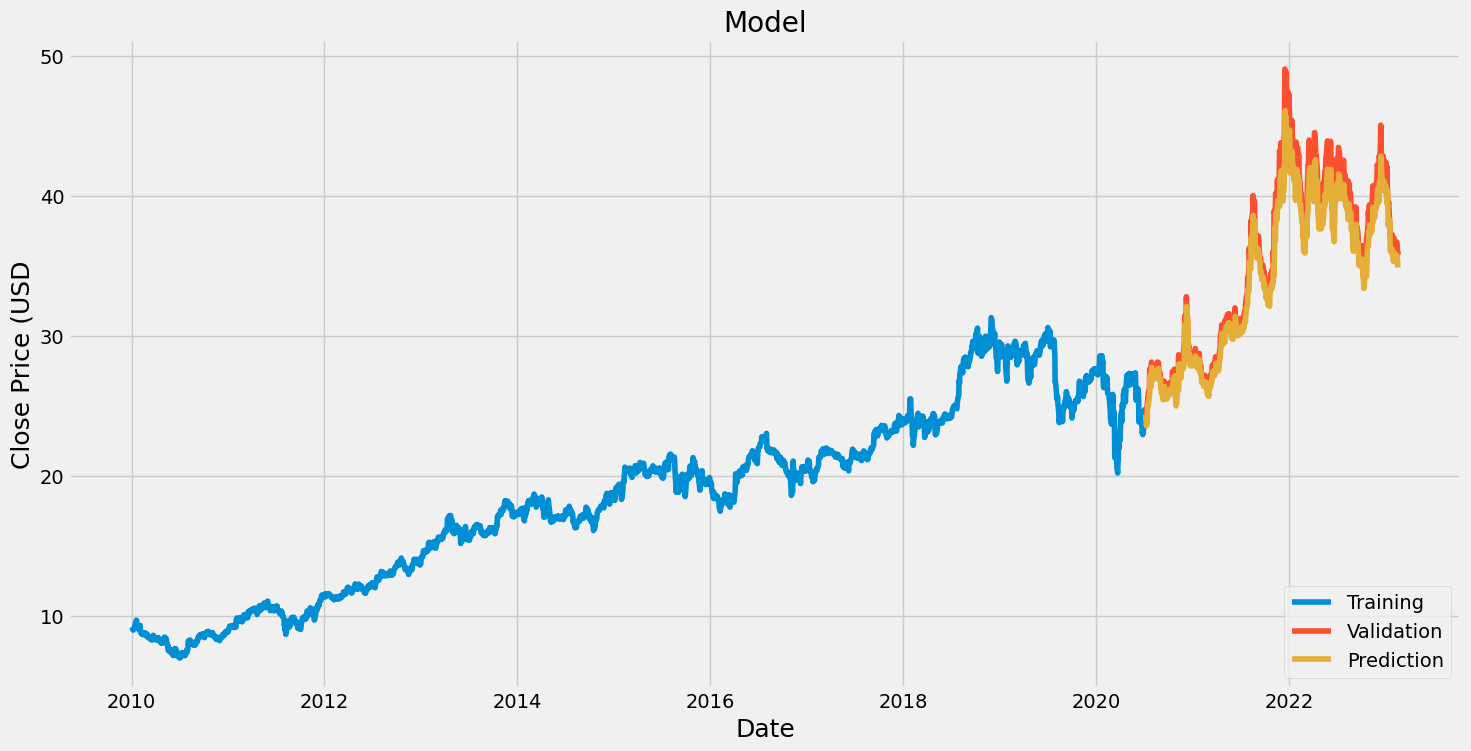

In [58]:
# Plot the data
data = pd.DataFrame(df['Close'].values, columns=['Close'], index=df.index)
train = data[:training_data_len].copy()
valid = data[training_data_len:].copy()
valid['Predictions'] = predictions

# Visulize the data
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price (USD', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Training', 'Validation', 'Prediction'], loc='lower right')
plt.show()

In [59]:
# Show the valid and predicted prices
print(valid)

                Close  Predictions
Date                              
2020-07-07  24.390068    24.394436
2020-07-08  24.189381    24.017122
2020-07-09  23.981529    23.767637
2020-07-10  24.246717    23.583340
2020-07-13  25.235796    23.829422
...               ...          ...
2023-02-13  36.705467    35.555065
2023-02-14  36.480183    35.722702
2023-02-15  36.146423    35.522865
2023-02-16  35.837685    35.181473
2023-02-17  36.054634    34.886242

[661 rows x 2 columns]


In [60]:
# Get the quote
# test_quote = web.DataReader('PFE', data_source='yahoo', start='2010-01-01', end='2021-10-20')
test_quote = yf.download('PFE', start='2010-01-01', end='2023-02-20')

# Create a new dataframe
last_80_days = test_quote['Close'].values[-80:].reshape(-1, 1)

# Scale the data to be values between 0 and 1
last_80_days_scaled = scaler.transform(last_80_days)
# Create an empty list
X_test = []
# Append the past 80 days
X_test.append(last_80_days_scaled)
# Convert the X_test data set to a numpy array
X_test = np.array(X_test)
# Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
# Get the predicted scaled price
pred_price = model.predict(X_test)
# Inverse scaling
pred_price = scaler.inverse_transform(pred_price)
print("Predicted Price:", pred_price)

[*********************100%***********************]  1 of 1 completed

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted Price: [[35.069054]]


In [61]:
# test_quote2 = web.DataReader('PFE', data_source='yahoo', start='2021-09-30', end='2021-10-21')
test_quote2 = yf.download('PFE', start='2010-01-01', end='2023-02-20')

print(test_quote2['Close'])

[*********************100%***********************]  1 of 1 completed

Ticker            PFE
Date                 
2010-01-04   9.200831
2010-01-05   9.069602
2010-01-06   9.040437
2010-01-07   9.006413
2010-01-08   9.079323
...               ...
2023-02-13  36.705467
2023-02-14  36.480183
2023-02-15  36.146423
2023-02-16  35.837685
2023-02-17  36.054634

[3305 rows x 1 columns]
